# Notebook 04 -- Training Forecaster (LSTM + Attention)
**Spendly AI -- Coding Camp 2026 powered by DBS Foundation (CC26-PSU276)**

**v2 Changes (sync NB01):**
- Tambah kategori `Transport` (total 9 kategori)
- `n_features` diupdate dari 8 → 9
- `build_forecaster` output Dense(9)
- Visualisasi grid diubah dari 4x2 → 5x2 (9 subplot)

**Improvements over baseline:**
- LSTM(64) → LSTM(32) → Custom Attention → Dense(32) → Dense(n_features)
- MinMaxScaler fit on train only
- Per-category MAE, RMSE, MAPE metrics
- Export to .keras format
- Target: MAE <= 0.02

In [1]:
import os, sys, time
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model
import matplotlib
import matplotlib.pyplot as plt
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except:
    pass
import joblib
import warnings
warnings.filterwarnings('ignore')

# PROJECT_ROOT sudah di-set oleh mount cell di atas
try:
    PROJECT_ROOT
except NameError:
    PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, os.path.join(PROJECT_ROOT, 'src'))

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
print(f"TF: {tf.__version__}")

# v2: Transport ditambahkan (total 9 kategori)
CATEGORIES = [
    "Beauty", "F&B", "Gas", "Groceries",
    "Health", "HouseHold", "Lifestyle", "Listrik", "Transport"
]
N_FEATURES = len(CATEGORIES)  # 9
print(f"Kategori ({N_FEATURES}): {CATEGORIES}")

TF: 2.10.0
Kategori (9): ['Beauty', 'F&B', 'Gas', 'Groceries', 'Health', 'HouseHold', 'Lifestyle', 'Listrik', 'Transport']


## 4.1 -- Generate Synthetic Time Series

In [2]:
def generate_spending_data(n_weeks=520, seed=42):
    """Generate 10 years of weekly spending data per category with realistic noise."""
    np.random.seed(seed)
    data = {}

    base_amounts = {
        "Beauty":    150000,
        "F&B":       500000,
        "Gas":       200000,
        "Groceries": 800000,
        "Health":    100000,
        "HouseHold": 300000,
        "Lifestyle": 250000,
        "Listrik":   350000,
        "Transport": 180000,  # v2: kategori baru
    }

    dates = pd.date_range(start='2024-01-01', periods=n_weeks, freq='W')

    for cat, base in base_amounts.items():
        trend    = np.linspace(0, base * 0.1, n_weeks)
        seasonal = base * 0.15 * np.sin(2 * np.pi * np.arange(n_weeks) / 52)
        noise    = np.random.normal(0, base * 0.005, n_weeks)
        values   = base + trend + seasonal + noise
        values   = np.maximum(values, base * 0.2)
        data[cat] = values

    df = pd.DataFrame(data, index=dates)
    return df

spending_df = generate_spending_data()
print(f"Shape: {spending_df.shape}")
print(spending_df.describe().round(0))

Shape: (520, 9)
         Beauty       F&B       Gas  Groceries    Health  HouseHold  \
count     520.0     520.0     520.0      520.0     520.0      520.0   
mean   157502.0  525140.0  210082.0   840077.0  105005.0   314990.0   
std     16254.0   53974.0   21557.0    86305.0   10800.0    32384.0   
min    127753.0  427705.0  171412.0   683100.0   84560.0   255976.0   
25%    142514.0  476102.0  190434.0   760868.0   94957.0   285317.0   
50%    157590.0  525358.0  210135.0   839489.0  104799.0   314103.0   
75%    171861.0  573105.0  229680.0   916901.0  114790.0   344812.0   
max    187162.0  624194.0  249499.0   992505.0  124311.0   374218.0   

       Lifestyle   Listrik  Transport  
count      520.0     520.0      520.0  
mean    262523.0  367420.0   188932.0  
std      27054.0   37775.0    19454.0  
min     213942.0  298621.0   151808.0  
25%     237461.0  332575.0   171320.0  
50%     262744.0  367424.0   189114.0  
75%     286831.0  402480.0   206753.0  
max     313007.0  436298

### Visualisasi Time Series

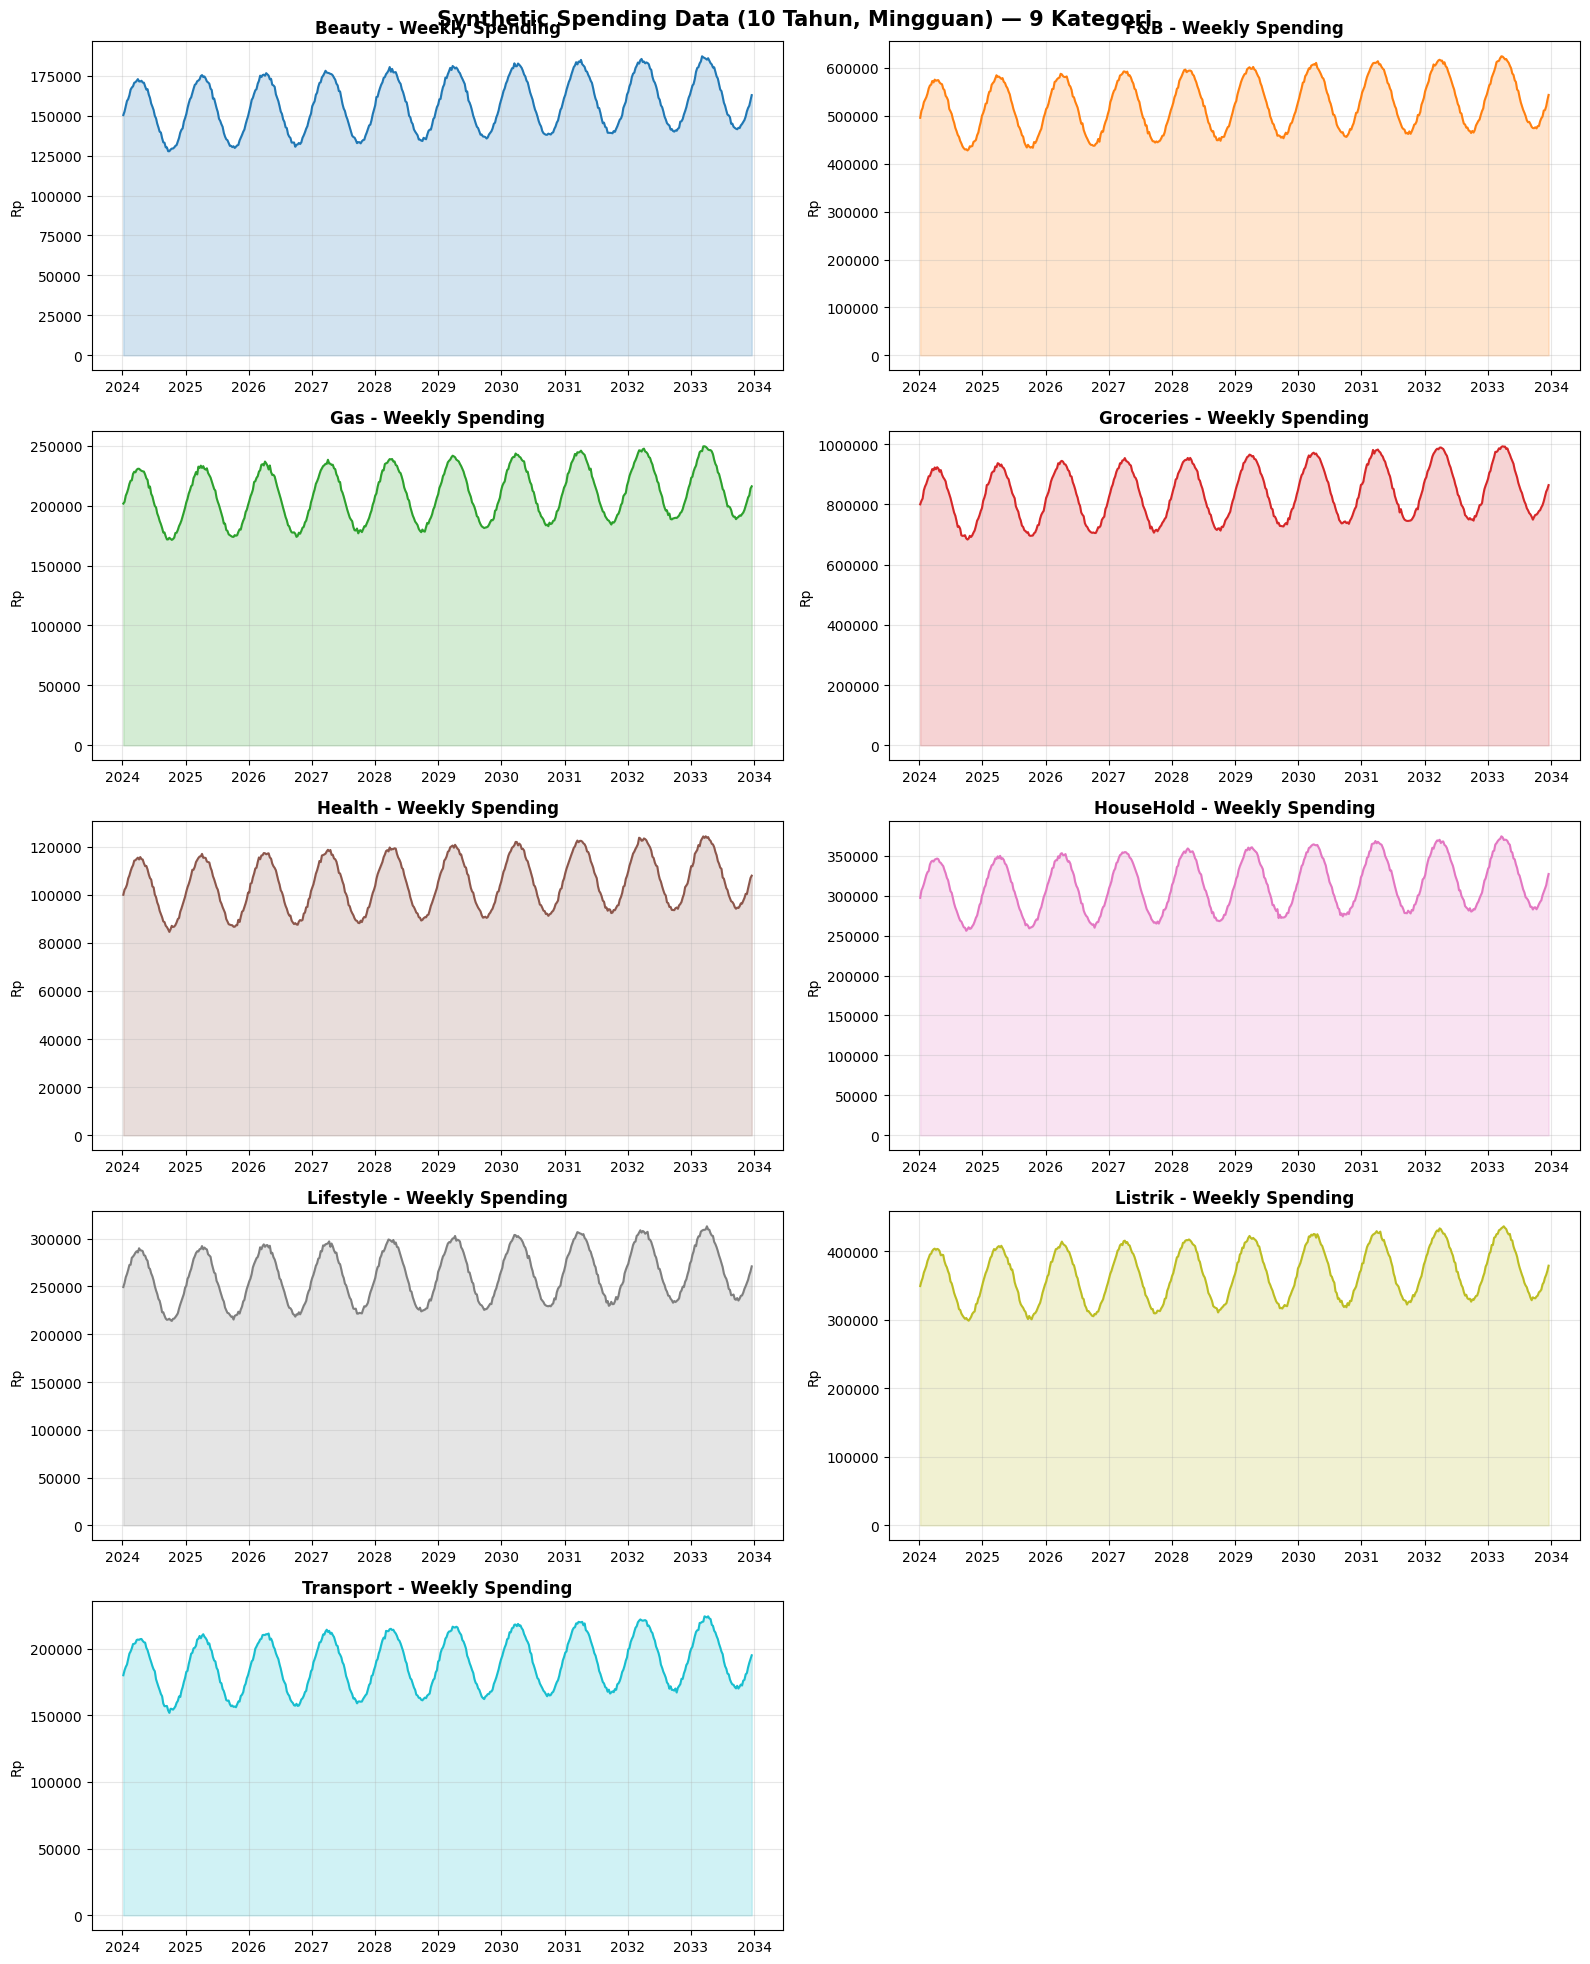

✅ Time series visualization saved.
Data saved: c:\file akmal\Capstone - Ai Eng - Spendly_ Workspace\data\_csv\synthetic_spending.csv


In [3]:
# v2: grid 5x2 untuk 9 kategori (subplot terakhir kosong)
fig, axes = plt.subplots(5, 2, figsize=(16, 20))
colors = plt.cm.tab10(np.linspace(0, 1, N_FEATURES))

for idx, cat in enumerate(CATEGORIES):
    ax = axes[idx // 2, idx % 2]
    ax.plot(spending_df.index, spending_df[cat], color=colors[idx], linewidth=1.5)
    ax.fill_between(spending_df.index, spending_df[cat], alpha=0.2, color=colors[idx])
    ax.set_title(f'{cat} - Weekly Spending', fontsize=12, fontweight='bold')
    ax.set_ylabel('Rp')
    ax.grid(alpha=0.3)
    ax.ticklabel_format(style='plain', axis='y')

# Sembunyikan subplot kosong (index 9 di grid 5x2)
axes[4, 1].set_visible(False)

plt.suptitle('Synthetic Spending Data (10 Tahun, Mingguan) — 9 Kategori', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, 'data', '_processed', 'forecaster_time_series.png'), dpi=150)
plt.show()
print("✅ Time series visualization saved.")

# Save CSV
spending_csv_path = os.path.join(PROJECT_ROOT, 'data', '_csv', 'synthetic_spending.csv')
spending_df.to_csv(spending_csv_path)
print(f"Data saved: {spending_csv_path}")

## 4.2 -- Prepare Sequences (MinMaxScaler fit on train only)

In [4]:
from sklearn.preprocessing import MinMaxScaler

LOOKBACK = 12  # 12 weeks lookback
HORIZON  = 1   # Predict next week

def create_sequences(data, lookback=LOOKBACK, horizon=HORIZON):
    X, y = [], []
    for i in range(len(data) - lookback - horizon + 1):
        X.append(data[i:i+lookback])
        y.append(data[i+lookback:i+lookback+horizon].flatten())
    return np.array(X), np.array(y)

# Temporal split FIRST, then scale
raw_values  = spending_df.values  # shape: (520, 9)
n_total     = len(raw_values)
train_end   = int(n_total * 0.8)
val_end     = int(n_total * 0.9)

raw_train = raw_values[:train_end]
raw_val   = raw_values[train_end:val_end]
raw_test  = raw_values[val_end:]

# Fit scaler on train data ONLY
scaler = MinMaxScaler()
scaler.fit(raw_train)
os.makedirs(os.path.join(PROJECT_ROOT, 'models', 'forecaster'), exist_ok=True)
joblib.dump(scaler, os.path.join(PROJECT_ROOT, 'models', 'forecaster', 'scaler.joblib'))
print("✅ MinMaxScaler fit on training data only")
print(f"   Scaler n_features_in_: {scaler.n_features_in_}  (expected: {N_FEATURES})")

# Scale all splits
scaled_all = scaler.transform(raw_values)

# Create sequences, then split temporally
X_all, y_all = create_sequences(scaled_all)
print(f"Total sequences: X={X_all.shape}, y={y_all.shape}")

n_seq          = len(X_all)
seq_train_end  = int(n_seq * 0.8)
seq_val_end    = int(n_seq * 0.9)

X_train, y_train = X_all[:seq_train_end],  y_all[:seq_train_end]
X_val,   y_val   = X_all[seq_train_end:seq_val_end], y_all[seq_train_end:seq_val_end]
X_test,  y_test  = X_all[seq_val_end:],    y_all[seq_val_end:]

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

BATCH_SIZE = 16
train_ds = tf.data.Dataset.from_tensor_slices(
    (X_train.astype(np.float32), y_train.astype(np.float32))
).shuffle(100, seed=SEED).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices(
    (X_val.astype(np.float32), y_val.astype(np.float32))
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices(
    (X_test.astype(np.float32), y_test.astype(np.float32))
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

✅ MinMaxScaler fit on training data only
   Scaler n_features_in_: 9  (expected: 9)
Total sequences: X=(508, 12, 9), y=(508, 9)
Train: (406, 12, 9), Val: (51, 12, 9), Test: (51, 12, 9)


## 4.3 -- Build LSTM + Attention Model

In [5]:
class AttentionLayer(tf.keras.layers.Layer):
    """Custom Attention layer for time series.
    Computes attention weights over LSTM output timesteps
    and returns a weighted context vector.
    """
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name='att_weight',
                                 shape=(input_shape[-1], input_shape[-1]),
                                 initializer='glorot_uniform', trainable=True)
        self.b = self.add_weight(name='att_bias',
                                 shape=(input_shape[-1],),
                                 initializer='zeros', trainable=True)
        self.u = self.add_weight(name='att_context',
                                 shape=(input_shape[-1],),
                                 initializer='glorot_uniform', trainable=True)

    def call(self, x):
        score              = tf.nn.tanh(tf.tensordot(x, self.W, axes=1) + self.b)
        attention_weights  = tf.nn.softmax(tf.tensordot(score, self.u, axes=1), axis=1)
        context            = tf.reduce_sum(x * tf.expand_dims(attention_weights, -1), axis=1)
        return context

    def get_config(self):
        return super().get_config()


def build_forecaster(lookback=LOOKBACK, n_features=N_FEATURES):
    """LSTM(64) → LSTM(32) → Attention → Dense(32) → Dense(n_features).
    v2: n_features=9 (Transport ditambahkan).
    """
    inputs  = tf.keras.Input(shape=(lookback, n_features))
    x       = tf.keras.layers.LSTM(64, return_sequences=True)(inputs)
    x       = tf.keras.layers.LSTM(32, return_sequences=True)(x)
    x       = AttentionLayer(name='attention')(x)
    x       = tf.keras.layers.Dense(32, activation='relu')(x)
    outputs = tf.keras.layers.Dense(n_features)(x)  # 9 output
    model   = tf.keras.Model(inputs, outputs, name="spendly_forecaster_attention_v2")
    return model


f_model = build_forecaster()
f_model.summary()
print(f"\nOutput shape: {f_model.output_shape}  (expected: (None, {N_FEATURES}))")

Model: "spendly_forecaster_attention_v2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 12, 9)]           0         
                                                                 
 lstm (LSTM)                 (None, 12, 64)            18944     
                                                                 
 lstm_1 (LSTM)               (None, 12, 32)            12416     
                                                                 
 attention (AttentionLayer)  (None, 32)                1088      
                                                                 
 dense (Dense)               (None, 32)                1056      
                                                                 
 dense_1 (Dense)             (None, 9)                 297       
                                                                 
Total params: 33,801
Trainable para

## 4.4 -- Training with GradientTape

In [6]:
f_loss_fn   = tf.keras.losses.MeanAbsoluteError()
f_optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

log_dir = os.path.join(PROJECT_ROOT, 'logs', 'forecaster')
os.makedirs(os.path.join(log_dir, 'train'), exist_ok=True)
os.makedirs(os.path.join(log_dir, 'val'),   exist_ok=True)
f_train_writer = tf.summary.create_file_writer(os.path.join(log_dir, 'train'))
f_val_writer   = tf.summary.create_file_writer(os.path.join(log_dir, 'val'))

@tf.function
def f_train_step(x, y):
    with tf.GradientTape() as tape:
        preds = f_model(x, training=True)
        loss  = f_loss_fn(y, preds)
    grads = tape.gradient(loss, f_model.trainable_variables)
    f_optimizer.apply_gradients(zip(grads, f_model.trainable_variables))
    return loss

@tf.function
def f_val_step(x, y):
    preds = f_model(x, training=False)
    return f_loss_fn(y, preds)

f_history    = {'train_loss': [], 'val_loss': []}
save_dir     = os.path.join(PROJECT_ROOT, 'models', 'forecaster')
os.makedirs(save_dir, exist_ok=True)
best_val_loss = float('inf')

EPOCHS      = 300
patience    = 30
wait        = 0
lr_patience = 15
lr_wait     = 0
min_lr      = 1e-6

print("=" * 60)
print(f"FORECASTER TRAINING v2 — {N_FEATURES} kategori (incl. Transport)")
print(f"LSTM(64→32) + Attention | MAE | LR=1e-3 | {EPOCHS} epochs max")
print("=" * 60)

for epoch in range(EPOCHS):
    t0   = time.time()
    tl_m = tf.keras.metrics.Mean()
    for x, y_b in train_ds:
        tl_m.update_state(f_train_step(x, y_b))

    vl_m = tf.keras.metrics.Mean()
    for x, y_b in val_ds:
        vl_m.update_state(f_val_step(x, y_b))

    tl      = tl_m.result().numpy()
    vl      = vl_m.result().numpy()
    elapsed = time.time() - t0

    f_history['train_loss'].append(tl)
    f_history['val_loss'].append(vl)

    with f_train_writer.as_default():
        tf.summary.scalar("loss", tl, step=epoch)
    with f_val_writer.as_default():
        tf.summary.scalar("loss", vl, step=epoch)

    marker = ""
    if vl < best_val_loss - 0.0001:
        best_val_loss = vl
        wait    = 0
        lr_wait = 0
        f_model.save_weights(os.path.join(save_dir, 'forecaster_weights.h5'))
        f_model.save(os.path.join(save_dir, 'forecaster.keras'))
        marker = " << BEST"
    else:
        wait    += 1
        lr_wait += 1
        if lr_wait >= lr_patience:
            current_lr = float(f_optimizer.learning_rate)
            new_lr     = max(current_lr * 0.5, min_lr)
            if new_lr < current_lr:
                f_optimizer.learning_rate.assign(new_lr)
                print(f"  ReduceLR: {current_lr:.2e} → {new_lr:.2e}")
            lr_wait = 0
        if wait >= patience:
            print(f"  Early stop at epoch {epoch+1}")
            break

    if (epoch + 1) % 10 == 0 or marker:
        current_lr = float(f_optimizer.learning_rate)
        print(f"  Epoch {epoch+1:3d}/{EPOCHS} | t_mae={tl:.5f} v_mae={vl:.5f} | lr={current_lr:.2e} | {elapsed:.1f}s{marker}")

print(f"\nBest val MAE: {best_val_loss:.5f}")
if best_val_loss <= 0.02:
    print("✅ TARGET MET (<= 0.02)")
else:
    print(f"⚠️  Val MAE: {best_val_loss:.5f} (target: <= 0.02)")

FORECASTER TRAINING v2 — 9 kategori (incl. Transport)
LSTM(64→32) + Attention | MAE | LR=1e-3 | 300 epochs max
  Epoch   1/300 | t_mae=0.28625 v_mae=0.21610 | lr=1.00e-03 | 4.4s << BEST
  Epoch   2/300 | t_mae=0.21874 v_mae=0.19504 | lr=1.00e-03 | 0.2s << BEST
  Epoch   3/300 | t_mae=0.19684 v_mae=0.18071 | lr=1.00e-03 | 0.1s << BEST
  Epoch   4/300 | t_mae=0.17241 v_mae=0.15494 | lr=1.00e-03 | 0.1s << BEST
  Epoch   5/300 | t_mae=0.10462 v_mae=0.09497 | lr=1.00e-03 | 0.2s << BEST
  Epoch   6/300 | t_mae=0.06872 v_mae=0.05375 | lr=1.00e-03 | 0.1s << BEST
  Epoch   7/300 | t_mae=0.03248 v_mae=0.02419 | lr=1.00e-03 | 0.1s << BEST
  Epoch   8/300 | t_mae=0.02945 v_mae=0.02130 | lr=1.00e-03 | 0.1s << BEST
  Epoch  10/300 | t_mae=0.02282 v_mae=0.02124 | lr=1.00e-03 | 0.1s
  Epoch  11/300 | t_mae=0.02686 v_mae=0.01959 | lr=1.00e-03 | 0.2s << BEST
  Epoch  12/300 | t_mae=0.02361 v_mae=0.01718 | lr=1.00e-03 | 0.1s << BEST
  Epoch  14/300 | t_mae=0.02660 v_mae=0.01662 | lr=1.00e-03 | 0.1s << BE

## 4.5 -- Training Curves

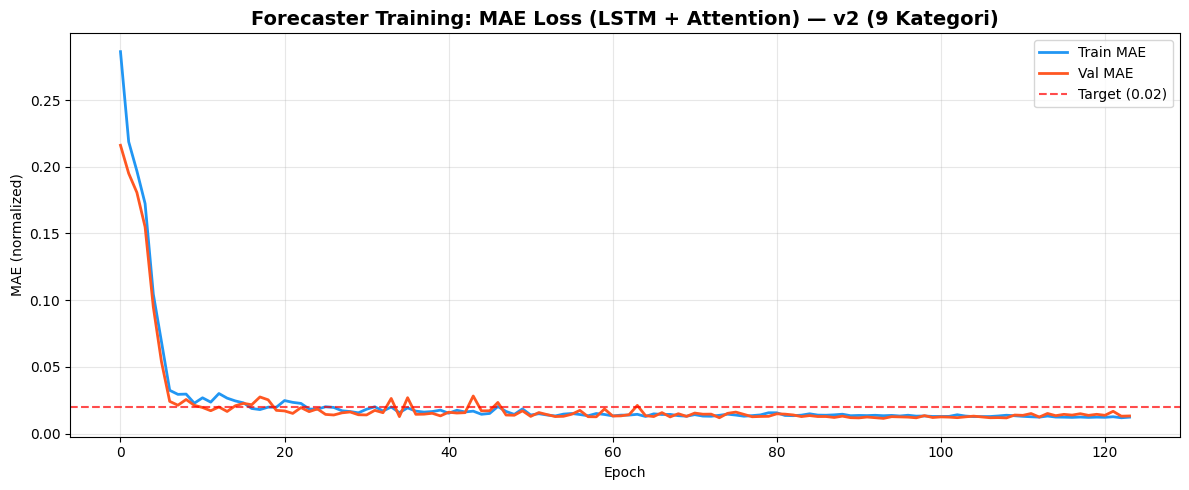

✅ Training curve saved.


In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(f_history['train_loss'], label='Train MAE', color='#2196F3', linewidth=2)
ax.plot(f_history['val_loss'],   label='Val MAE',   color='#FF5722', linewidth=2)
ax.axhline(y=0.02, color='red', linestyle='--', alpha=0.7, label='Target (0.02)')
ax.set_title('Forecaster Training: MAE Loss (LSTM + Attention) — v2 (9 Kategori)', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('MAE (normalized)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, 'data', '_processed', 'forecaster_training_curve.png'), dpi=150)
plt.show()
print("✅ Training curve saved.")

## 4.6 -- Test Evaluation & Per-Category Metrics

In [8]:
f_model.load_weights(os.path.join(save_dir, 'forecaster_weights.h5'))
tf.saved_model.save(f_model, os.path.join(save_dir, 'forecaster_saved'))
print("✅ Forecaster model saved (weights + .keras + SavedModel)")

# Test predictions
all_preds = []
all_trues = []
for x, y_b in test_ds:
    preds = f_model(x, training=False)
    all_preds.append(preds.numpy())
    all_trues.append(y_b.numpy())

all_preds = np.concatenate(all_preds, axis=0)
all_trues = np.concatenate(all_trues, axis=0)

test_mae = np.mean(np.abs(all_preds - all_trues))
print(f"\nTest MAE (normalized): {test_mae:.5f}")

# Inverse transform
preds_real = scaler.inverse_transform(all_preds)
trues_real = scaler.inverse_transform(all_trues)

INFO:tensorflow:Assets written to: c:\file akmal\Capstone - Ai Eng - Spendly_ Workspace\models\forecaster\forecaster_saved\assets


INFO:tensorflow:Assets written to: c:\file akmal\Capstone - Ai Eng - Spendly_ Workspace\models\forecaster\forecaster_saved\assets


✅ Forecaster model saved (weights + .keras + SavedModel)

Test MAE (normalized): 0.01287


In [9]:
# --- Per-Category Metrics: MAE, RMSE, MAPE ---
print("\n" + "=" * 70)
print("PER-CATEGORY EVALUATION METRICS")
print("=" * 70)
print(f"  {'Category':12s} {'MAE (norm)':>10s} {'MAE (Rp)':>12s} {'RMSE (Rp)':>12s} {'MAPE':>8s}")
print(f"  {'-'*55}")

per_cat_metrics = []
for idx, cat in enumerate(CATEGORIES):
    cat_preds      = all_preds[:, idx]
    cat_trues      = all_trues[:, idx]
    cat_mae_norm   = np.mean(np.abs(cat_preds - cat_trues))
    cat_preds_real = preds_real[:, idx]
    cat_trues_real = trues_real[:, idx]
    cat_mae_real   = np.mean(np.abs(cat_preds_real - cat_trues_real))
    cat_rmse_real  = np.sqrt(np.mean((cat_preds_real - cat_trues_real) ** 2))
    cat_mape       = np.mean(np.abs((cat_trues_real - cat_preds_real) / np.maximum(cat_trues_real, 1))) * 100

    per_cat_metrics.append({
        'category': cat, 'mae_norm': cat_mae_norm,
        'mae_rp': cat_mae_real, 'rmse_rp': cat_rmse_real, 'mape': cat_mape
    })
    print(f"  {cat:12s} {cat_mae_norm:10.5f} {cat_mae_real:12,.0f} {cat_rmse_real:12,.0f} {cat_mape:7.2f}%")

overall_mae_real  = np.mean(np.abs(preds_real - trues_real))
overall_rmse_real = np.sqrt(np.mean((preds_real - trues_real) ** 2))
print(f"\n  {'OVERALL':12s} {test_mae:10.5f} {overall_mae_real:12,.0f} {overall_rmse_real:12,.0f}")

if test_mae <= 0.02:
    print("\n✅ TARGET MET (Test MAE <= 0.02)")
else:
    print(f"\n⚠️ Test MAE: {test_mae:.5f} (target: <= 0.02)")


PER-CATEGORY EVALUATION METRICS
  Category     MAE (norm)     MAE (Rp)    RMSE (Rp)     MAPE
  -------------------------------------------------------
  Beauty          0.01250          714          925    0.43%
  F&B             0.01038        1,933        2,448    0.36%
  Gas             0.01411        1,050        1,286    0.48%
  Groceries       0.01151        3,436        4,369    0.40%
  Health          0.01379          524          630    0.48%
  HouseHold       0.01391        1,563        1,948    0.47%
  Lifestyle       0.01314        1,222        1,495    0.44%
  Listrik         0.01348        1,759        2,108    0.46%
  Transport       0.01303          889        1,073    0.45%

  OVERALL         0.01287        1,454        2,098

✅ TARGET MET (Test MAE <= 0.02)


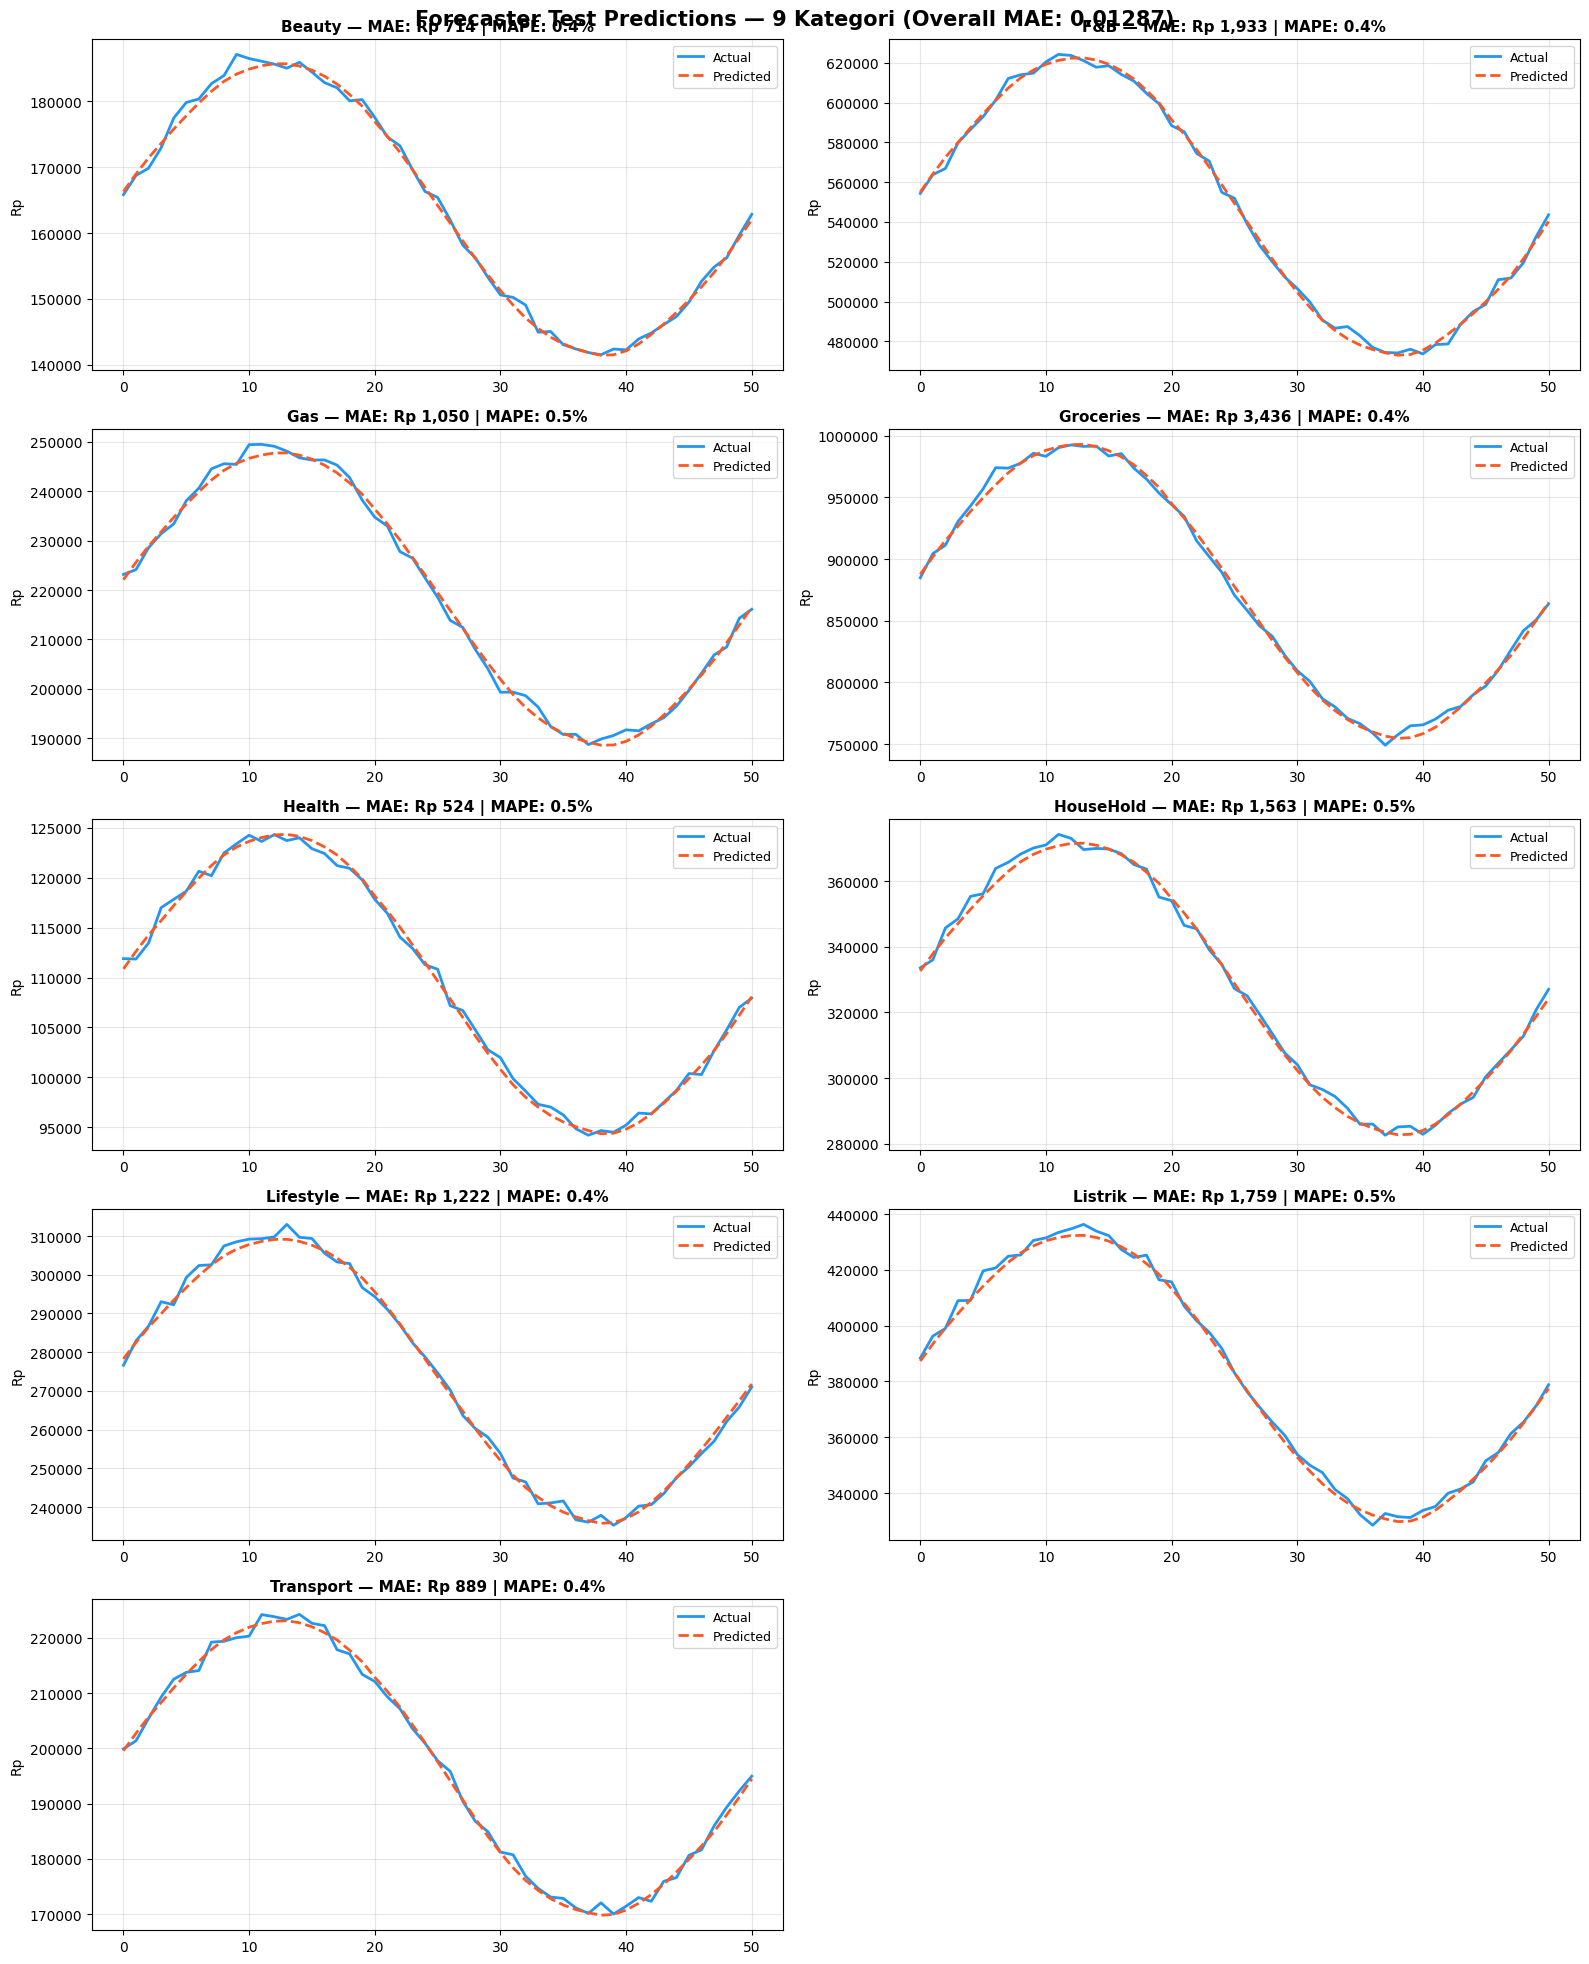

✅ Prediction visualization saved.


In [10]:
# --- Prediction vs Actual visualization ---
# v2: grid 5x2 untuk 9 kategori
fig, axes = plt.subplots(5, 2, figsize=(16, 20))

for idx, cat in enumerate(CATEGORIES):
    ax = axes[idx // 2, idx % 2]
    ax.plot(trues_real[:, idx], label='Actual',    color='#2196F3', linewidth=2)
    ax.plot(preds_real[:, idx], label='Predicted', color='#FF5722', linewidth=2, linestyle='--')
    m = per_cat_metrics[idx]
    ax.set_title(f'{cat} — MAE: Rp {m["mae_rp"]:,.0f} | MAPE: {m["mape"]:.1f}%',
                 fontsize=11, fontweight='bold')
    ax.set_ylabel('Rp')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.ticklabel_format(style='plain', axis='y')

# Sembunyikan subplot kosong
axes[4, 1].set_visible(False)

plt.suptitle(f'Forecaster Test Predictions — 9 Kategori (Overall MAE: {test_mae:.5f})',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, 'data', '_processed', 'forecaster_predictions.png'), dpi=150)
plt.show()
print("✅ Prediction visualization saved.")

In [11]:
print(f"""
=====================================================
LAPORAN: Notebook 04 v2 -- Training Forecaster
=====================================================

v2 CHANGES (sync NB01):
- Tambah kategori Transport (total 9 kategori)
- n_features: 8 → 9
- build_forecaster output Dense(9)
- Visualisasi grid: 4x2 → 5x2
- base_amounts Transport: Rp 180.000/minggu

ARSITEKTUR:
- LSTM(64, return_sequences) → LSTM(32, return_sequences)
  → AttentionLayer → Dense(32) → Dense(9)
- MinMaxScaler fit on train only
- MAE loss, Adam optimizer, ReduceLR + EarlyStopping manual

HASIL:
- Data: Synthetic 10-year weekly spending (9 categories)
- Best Val MAE : {best_val_loss:.5f}
- Test MAE     : {test_mae:.5f}

OUTPUT FILES:
- models/forecaster/forecaster_weights.h5
- models/forecaster/forecaster.keras
- models/forecaster/forecaster_saved/
- models/forecaster/scaler.joblib
- data/_csv/synthetic_spending.csv
=====================================================
""")


LAPORAN: Notebook 04 v2 -- Training Forecaster

v2 CHANGES (sync NB01):
- Tambah kategori Transport (total 9 kategori)
- n_features: 8 → 9
- build_forecaster output Dense(9)
- Visualisasi grid: 4x2 → 5x2
- base_amounts Transport: Rp 180.000/minggu

ARSITEKTUR:
- LSTM(64, return_sequences) → LSTM(32, return_sequences)
  → AttentionLayer → Dense(32) → Dense(9)
- MinMaxScaler fit on train only
- MAE loss, Adam optimizer, ReduceLR + EarlyStopping manual

HASIL:
- Data: Synthetic 10-year weekly spending (9 categories)
- Best Val MAE : 0.01144
- Test MAE     : 0.01287

OUTPUT FILES:
- models/forecaster/forecaster_weights.h5
- models/forecaster/forecaster.keras
- models/forecaster/forecaster_saved/
- models/forecaster/scaler.joblib
- data/_csv/synthetic_spending.csv

